# Regression — Insurance Premium Prediction (no-`Pipeline` variant)
**Dataset:** `data/playground-series-s4e12/train.csv` (1,200,000 rows x 21 columns).

**Problem statement:** Predict **`Premium Amount`** (a continuous insurance premium) from customer demographic, policy and health attributes.

**How this notebook differs from `regression_insurance_premium_1.ipynb`:** the original wraps preprocessing + model into a single `sklearn.pipeline.Pipeline` object per algorithm and loops over a `{name: pipeline}` dict to train all ten. Here, preprocessing (imputation, scaling, one-hot encoding, polynomial expansion) is done via small **plain Python functions** — no `ColumnTransformer`, no `Pipeline` — producing NumPy arrays that each algorithm's **own standalone cell** fits directly.

 - Data loading & audit.
 - Exploratory Data Analysis (EDA).
 - Data cleaning, feature engineering.
 - Manual encoding, scaling & two train/test splits (no `ColumnTransformer`).
 - **One dedicated cell per algorithm** — all 10 regression algorithms (R², RMSE, MAE).
 - Hyperparameter tuning (GridSearchCV, applied directly to the raw estimator) on the two best models.
 - 5-fold cross-validated R² for the two best models, using a **manual K-fold loop that refits preprocessing on every fold** (no leakage).
 - Result visualisation (residuals, predicted-vs-actual, feature importance).

**Scale note:** at 1.2M rows, not every algorithm is equally tractable. **Decision Tree, Random Forest, Gradient Boosting, and SVR** — repeated tree-building across many estimators/depths during tuning, and SVR's O(n²)-O(n³) fit time — are trained and evaluated on a fixed-seed **100,000-row random subsample** (80:20 split). Every other algorithm (**Linear, Ridge, Lasso, ElasticNet, Polynomial Regression, KNN Regressor**) is fast/scalable enough to train and evaluate on the **full 1.2M-row dataset** (80:20 split) instead. This is documented explicitly at the point of splitting below (Section B3).

Random seed `42` is used everywhere for reproducibility.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 100

DATA_PATH = '../data/playground-series-s4e12/train.csv'

## Section A — Dataset Loading & Audit

In [2]:
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Data types:')
print(df.dtypes)

Shape: 1,200,000 rows x 21 columns

Data types:
id                        int64
Age                     float64
Gender                   object
Annual Income           float64
Marital Status           object
Number of Dependents    float64
Education Level          object
Occupation               object
Health Score            float64
Location                 object
Policy Type              object
Previous Claims         float64
Vehicle Age             float64
Credit Score            float64
Insurance Duration      float64
Policy Start Date        object
Customer Feedback        object
Smoking Status           object
Exercise Frequency       object
Property Type            object
Premium Amount          float64
dtype: object


In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values (count, % of 1.2M rows):')
for col, n in missing.items():
    print(f'  {col}: {n:,} ({n / len(df):.2%})')

print(f'\nDuplicate rows: {df.duplicated().sum()}')

print('\nTarget (Premium Amount) distribution:')
print(df['Premium Amount'].describe())
print(f"Skewness: {df['Premium Amount'].skew():.3f}")

Columns with missing values (count, % of 1.2M rows):
  Previous Claims: 364,029 (30.34%)
  Occupation: 358,075 (29.84%)
  Credit Score: 137,882 (11.49%)
  Number of Dependents: 109,672 (9.14%)
  Customer Feedback: 77,824 (6.49%)
  Health Score: 74,076 (6.17%)
  Annual Income: 44,949 (3.75%)
  Age: 18,705 (1.56%)
  Marital Status: 18,529 (1.54%)
  Vehicle Age: 6 (0.00%)
  Insurance Duration: 1 (0.00%)



Duplicate rows: 0

Target (Premium Amount) distribution:
count    1.200000e+06
mean     1.102545e+03
std      8.649989e+02
min      2.000000e+01
25%      5.140000e+02
50%      8.720000e+02
75%      1.509000e+03
max      4.999000e+03
Name: Premium Amount, dtype: float64
Skewness: 1.241


**Observation:** The dataset has 1.2M rows and 21 columns, with **no duplicate rows** but substantial missingness in several columns — `Occupation` (~30%), `Previous Claims` (~30%), `Credit Score` (~11%), `Customer Feedback` (~6%), `Health Score` (~6%), `Number of Dependents` (~9%), `Annual Income` (~4%). Given the scale (hundreds of thousands of missing values per affected column), dropping rows is not viable — imputation is required (Section B). `Premium Amount` is right-skewed (skewness ≈ 1.24), typical of monetary targets.

## Section A — EDA Visualisations

Plots below use a **50,000-row random sample** of the 1.2M rows for rendering speed/readability only (histograms, scatter, correlations are all stable well below that size); tabular statistics above were computed on the full dataset.

### A.1 Distribution of every numeric feature

8 numeric columns, 10 categorical columns


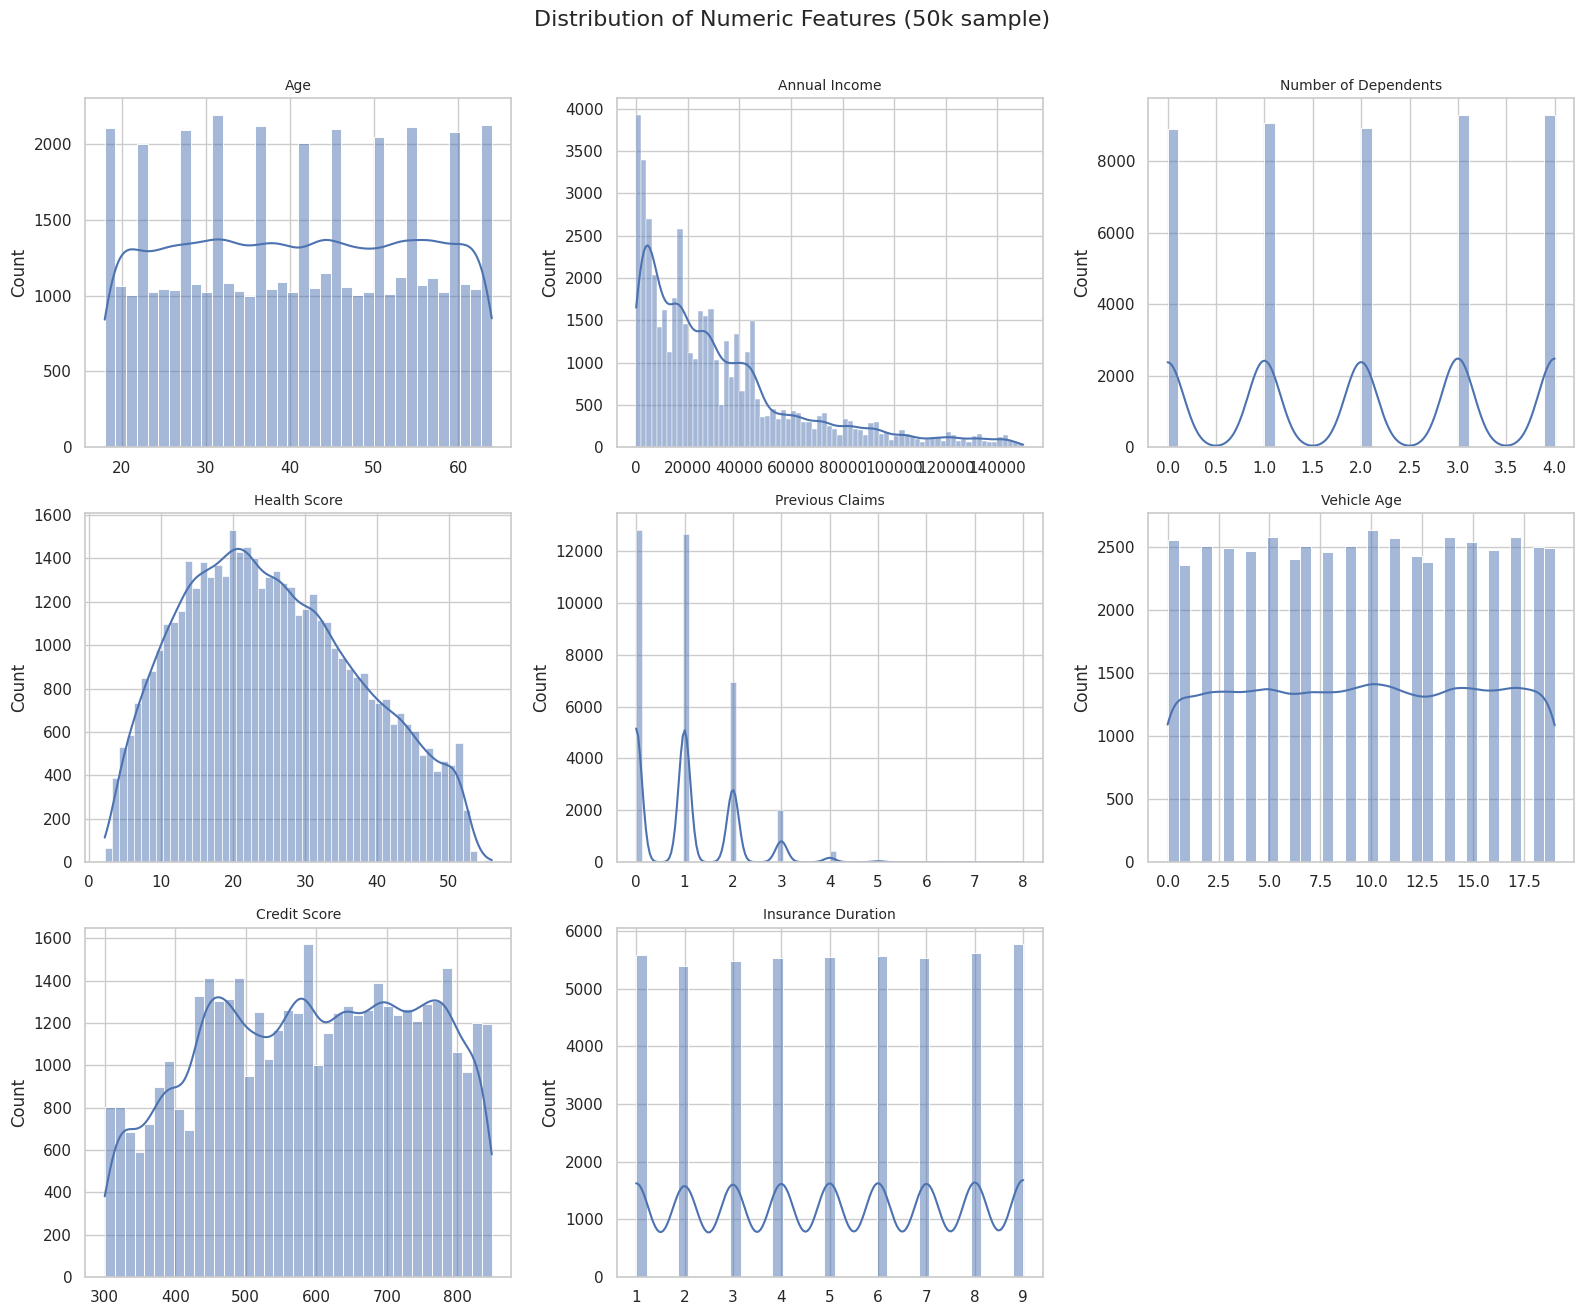

In [4]:
eda_df = df.sample(50000, random_state=RANDOM_STATE)

numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ['id', 'Premium Amount']]
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Policy Start Date')  # date column, handled separately

print(f'{len(numeric_cols)} numeric columns, {len(categorical_cols)} categorical columns')

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(eda_df[col], kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle('Distribution of Numeric Features (50k sample)', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('../models/reg2_numeric_distributions.png', bbox_inches='tight')
plt.show()

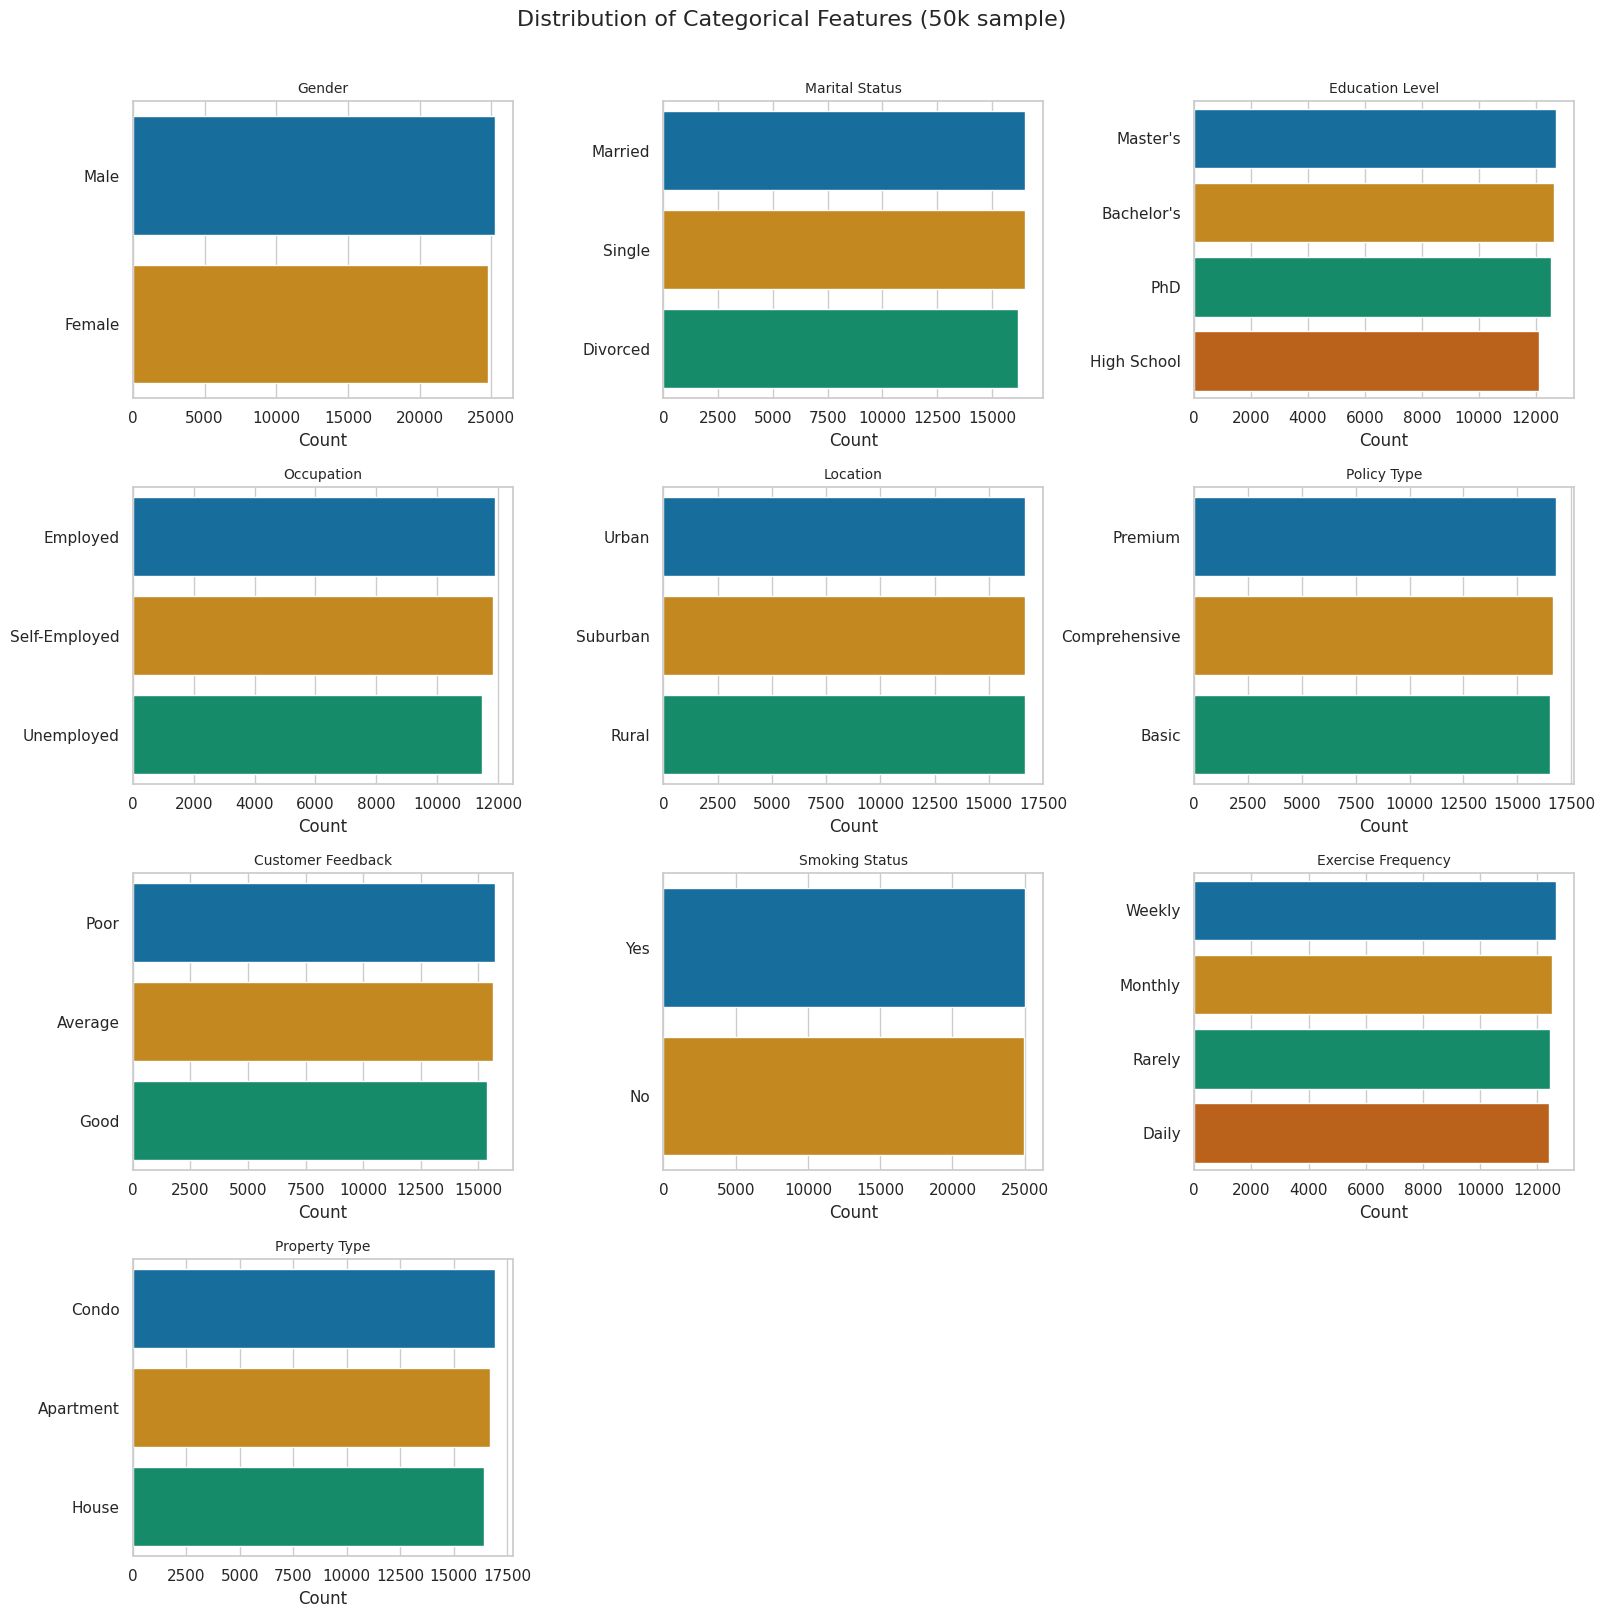

In [5]:
n_cat = len(categorical_cols)
ncols = 3
nrows = int(np.ceil(n_cat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    order = eda_df[col].value_counts().index
    sns.countplot(y=eda_df[col], order=order, ax=axes[i], palette='colorblind')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')
for j in range(n_cat, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle('Distribution of Categorical Features (50k sample)', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('../models/reg2_categorical_distributions.png', bbox_inches='tight')
plt.show()

**Observation:** Most numeric features (`Age`, `Credit Score`, `Vehicle Age`, `Insurance Duration`) are close to uniformly distributed (skew ≈ 0), consistent with a synthetic Kaggle Playground dataset. `Annual Income` is the exception — clearly right-skewed (skew ≈ 1.5), as expected for a monetary feature. Categorical features are all roughly balanced across their categories (2-4 levels each), with no single category dominating — so one-hot encoding is cheap and there's no severe class-imbalance concern on the feature side.

### A.2 Correlation heatmap

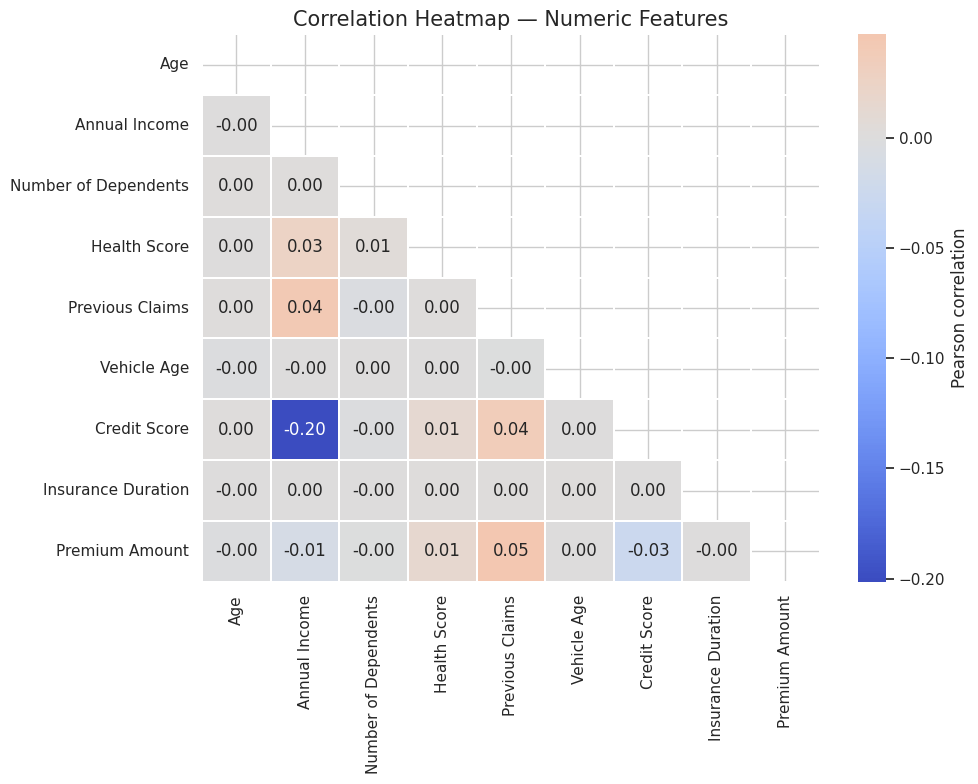

Correlation with Premium Amount:
Previous Claims         0.046874
Credit Score            0.026014
Health Score            0.014704
Annual Income           0.012390
Age                     0.002430
Number of Dependents    0.000976
Vehicle Age             0.000391
Insurance Duration      0.000028
Name: Premium Amount, dtype: float64


In [6]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols + ['Premium Amount']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.3,
            cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation Heatmap — Numeric Features', fontsize=15)
plt.tight_layout()
plt.savefig('../models/reg2_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Correlation with Premium Amount:')
print(corr['Premium Amount'].drop('Premium Amount').abs().sort_values(ascending=False))

**Observation:** Every numeric feature has a **near-zero linear correlation** with `Premium Amount` (all |r| < 0.05 — even the strongest, `Previous Claims`, barely reaches 0.047). This is a known characteristic of this particular Kaggle Playground competition (S4E12): the target is deliberately noisy and any real signal is weak and likely spread thinly across many categorical interactions rather than concentrated in a few numeric features. This sets a realistic expectation for Section C: R² scores here will be **far lower** than in the Loan-dataset regression notebook, and that is the correct, expected outcome for this dataset — not a pipeline error.

### A.3 Target distribution

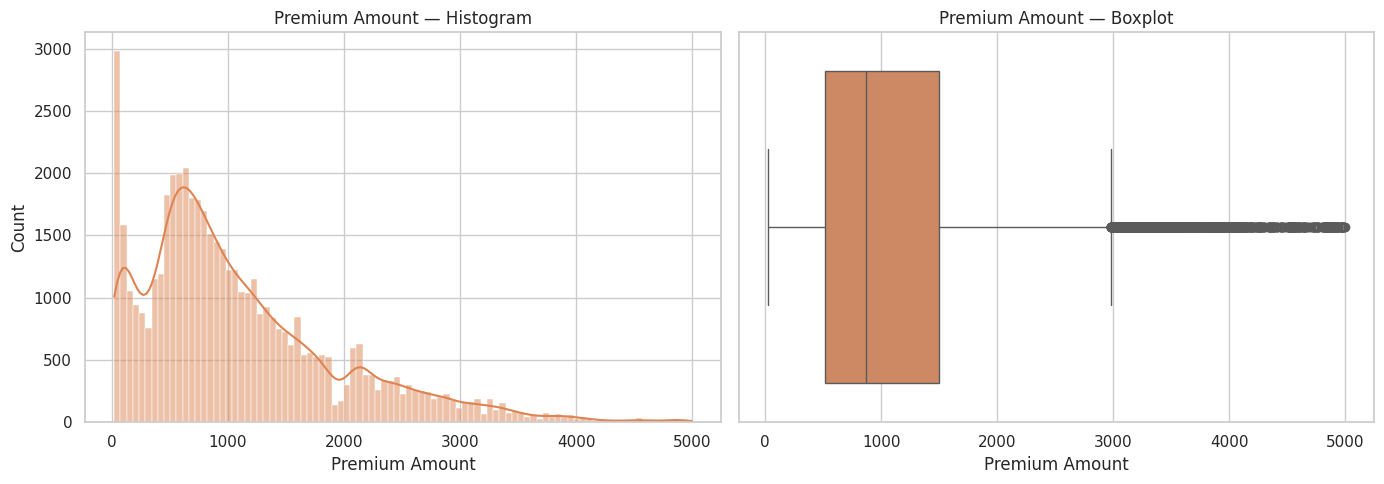

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(eda_df['Premium Amount'], kde=True, ax=axes[0], color='#DD8452')
axes[0].set_title('Premium Amount — Histogram')

sns.boxplot(x=eda_df['Premium Amount'], ax=axes[1], color='#DD8452')
axes[1].set_title('Premium Amount — Boxplot')

plt.tight_layout()
plt.savefig('../models/reg2_target_distribution.png', bbox_inches='tight')
plt.show()

**Observation:** `Premium Amount` is right-skewed with a long tail of high-value premiums and a hard floor near 20 (its minimum) — a shape typical of insurance premiums, where most policies cluster at lower/mid values but a minority carry much higher premiums.

### A.4 Feature–target scatter plots

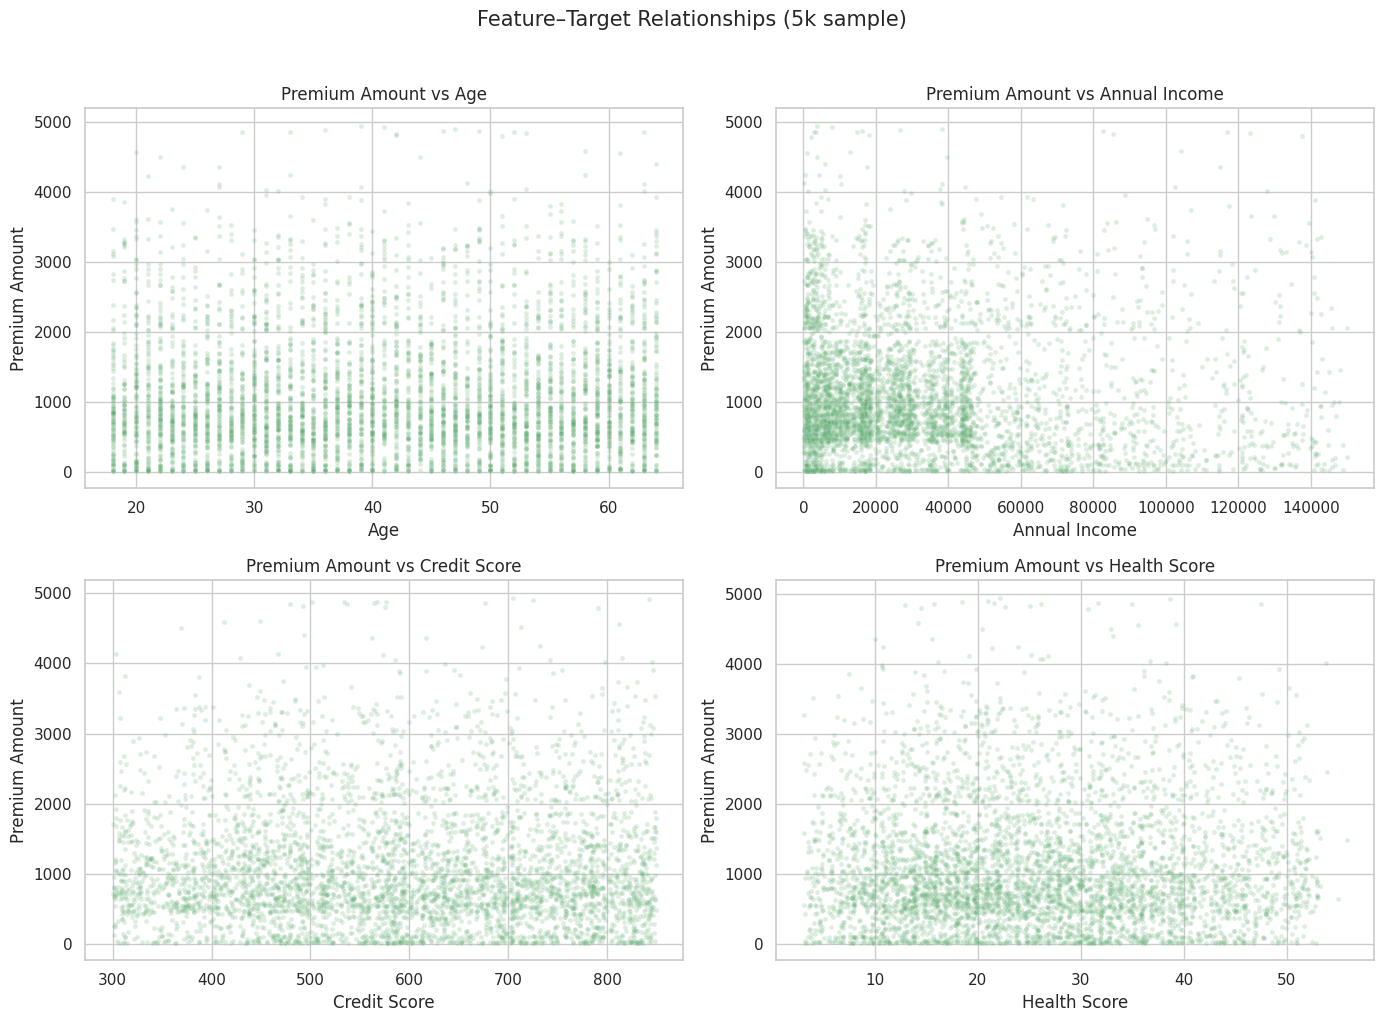

In [8]:
scatter_features = ['Age', 'Annual Income', 'Credit Score', 'Health Score']
scatter_sample = eda_df.sample(5000, random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(scatter_features):
    sns.scatterplot(x=scatter_sample[col], y=scatter_sample['Premium Amount'], ax=axes[i], alpha=0.2, s=12, color='#55A868')
    axes[i].set_title(f'Premium Amount vs {col}')
fig.suptitle('Feature–Target Relationships (5k sample)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../models/reg2_scatter_feature_target.png', bbox_inches='tight')
plt.show()

**Observation:** These scatter plots visually confirm the correlation heatmap — no clear trend line is visible for any single feature against `Premium Amount`; the point clouds are essentially flat/uniform bands. This reinforces that no individual numeric feature drives the premium on its own.